In [3]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/datasets/raw_loan_prediction_dataset.csv")

In [5]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [6]:
df.columns

Index(['age', 'gender', 'marital_status', 'education_level', 'annual_income',
       'monthly_income', 'employment_status', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate',
       'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts',
       'total_credit_limit', 'current_balance', 'delinquency_history',
       'public_records', 'num_of_delinquencies', 'loan_paid_back'],
      dtype='object')

In [7]:
df.shape

(20000, 22)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

In [9]:
df.isnull().sum()

,0
age,0
gender,0
marital_status,0
education_level,0
annual_income,0
monthly_income,0
employment_status,0
debt_to_income_ratio,0
credit_score,0
loan_amount,0


##TARGET VARIABLE IS "Loan_Paid_Back"

## Data Cleaning

- Checked dataset shape and structure.
- Verified data types.
- Checked for missing values (none found).
- Checked for duplicate records (none found).
- Confirmed target variable availability.

In [10]:
df['loan_paid_back'].value_counts()
df.describe()

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637765,3629.136466,0.177019,679.25695,15129.300909,12.400627,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


In [11]:
df['loan_paid_back'].value_counts(normalize=True) * 100

,proportion
loan_paid_back,
1,79.99
0,20.01


##EXPLORATORY DATA ANALYSIS (EDA)

***1. LOAN REPAYMENT DISTRIBUTION***

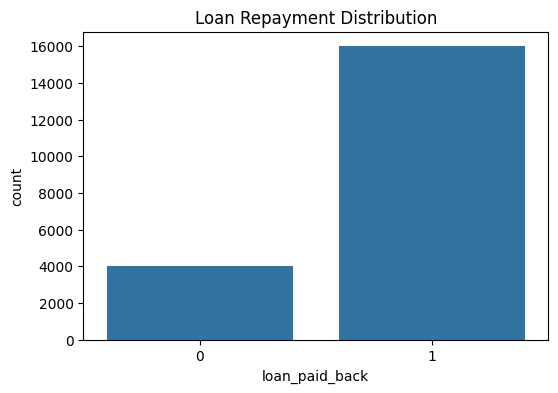

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x="loan_paid_back", data=df)

plt.title("Loan Repayment Distribution")

plt.show()

### Insight



- Approximately 80% of borrowers successfully repaid their loans, while about 20% did not.


- The dataset is moderately imbalanced, with repayment cases significantly outnumbering non-repayment cases.


- This indicates that accuracy alone may not be sufficient for model evaluation, and additional metrics such as precision, recall, and F1-score should be considered.

***2. CREDIT SCORE VS LOAN REPAYMENT***

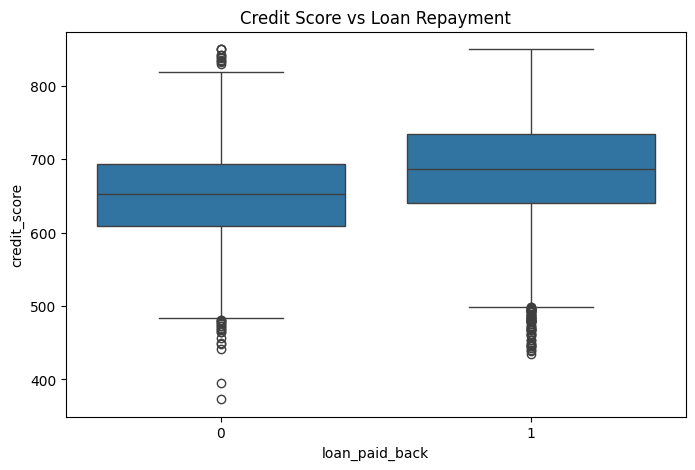

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_paid_back",
    y="credit_score",
    data=df
)

plt.title("Credit Score vs Loan Repayment")

plt.show()

### Insight



- Borrowers who successfully repaid their loans generally have higher credit scores than those who did not.


- The median credit score for repaid loans is noticeably higher, suggesting a strong relationship between creditworthiness and repayment behavior.


- Credit score appears to be one of the most important predictors for loan repayment and is likely to be a significant feature in the machine learning model.

- Several outliers are present in both groups, indicating that some borrowers with low credit scores still repaid their loans, while a few borrowers with high credit scores failed to repay.

***3. DEBT TO INCOME RATIO VS LOAN REPAYMENT***

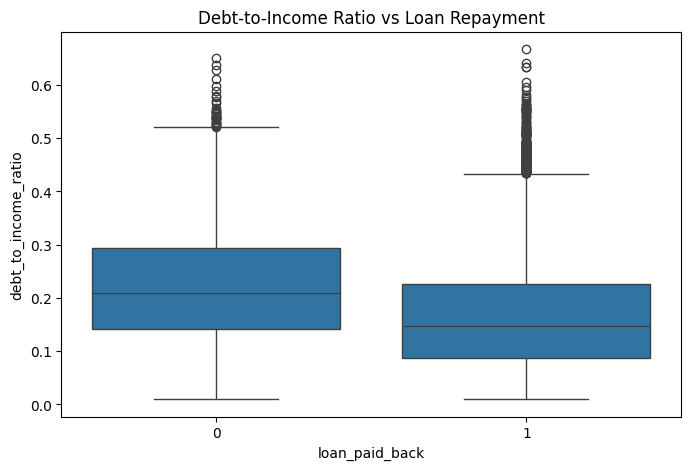

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_paid_back",
    y="debt_to_income_ratio",
    data=df
)

plt.title("Debt-to-Income Ratio vs Loan Repayment")

plt.show()

### Insight



- Borrowers who did not repay their loans generally have higher debt-to-income ratios compared to those who successfully repaid.


- The median debt-to-income ratio is noticeably higher for defaulted loans, suggesting that existing debt burden has a significant impact on repayment ability.


- Debt-to-income ratio appears to be an important risk indicator and is likely to contribute strongly to the predictive model.


-Although some borrowers with high debt-to-income ratios still repaid their loans, the overall trend indicates that increasing debt burden is associated with higher default risk.

***4. ANNUAL INCOME VS LOAN REPAYMENT***

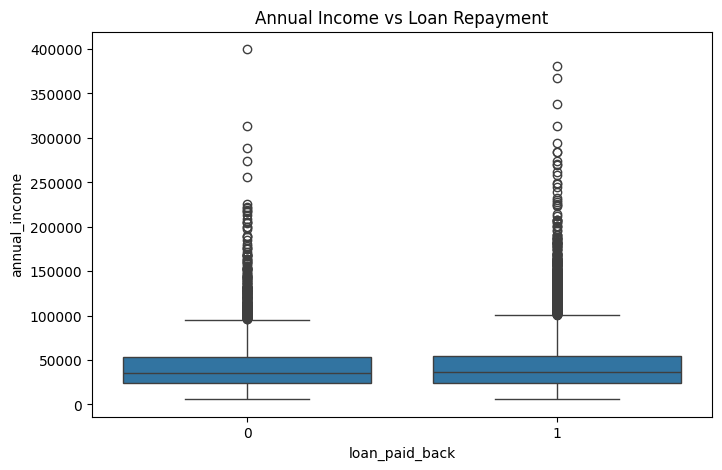

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_paid_back",
    y="annual_income",
    data=df
)

plt.title("Annual Income vs Loan Repayment")

plt.show()

### Insight

- Borrowers who repaid their loans tend to have slightly higher annual incomes than those who did not.


- The difference in median income between the two groups is relatively small, suggesting that annual income alone may not be a strong predictor of loan repayment.


- Income may still contribute to repayment behavior when combined with other factors such as credit score, debt-to-income ratio, and loan amount.

- Both groups contain numerous high-income outliers, indicating that a high income does not guarantee successful loan repayment.

***5. CORRELATION HEATMAP***

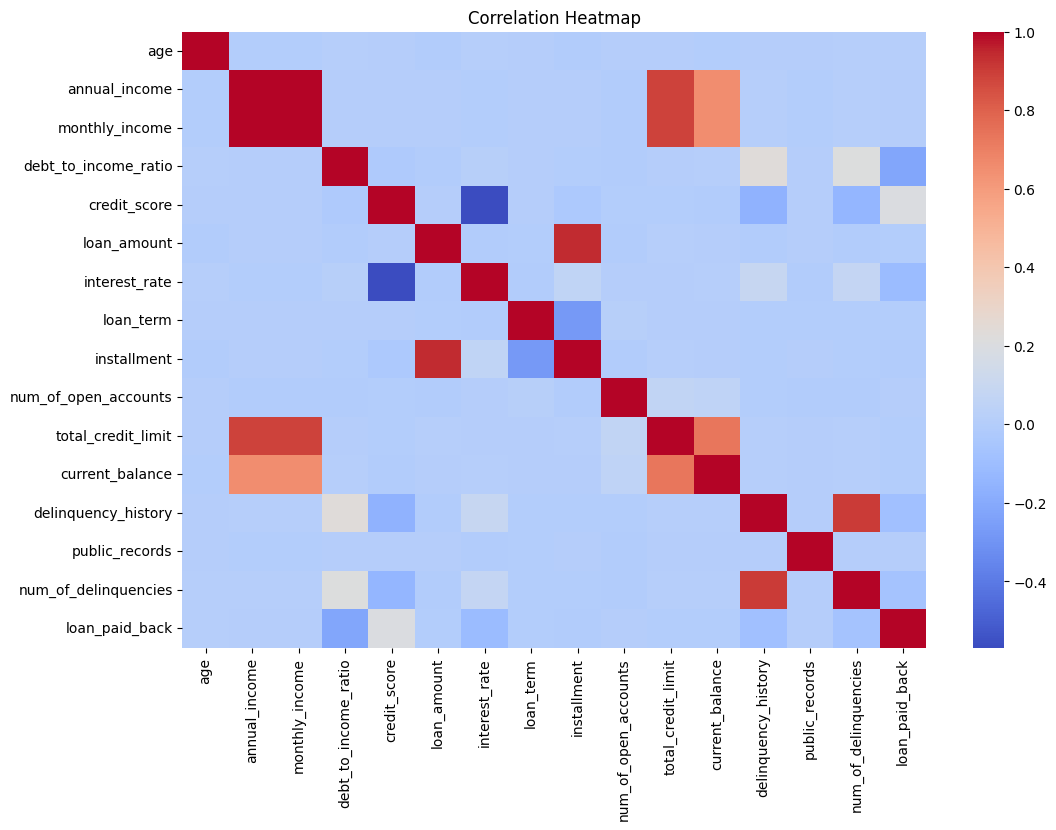

In [16]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(
    include=["int64", "float64"]
).corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

***INSIGHTS***

Borrowers with higher credit scores tend to receive lower interest rates and are more likely to repay loans successfully. In contrast, higher debt-to-income ratios and delinquency records are associated with lower repayment probability. These relationships suggest that creditworthiness and payment history are key factors in predicting loan default.

In [17]:
# Separating Features and Targets
X = df.drop("loan_paid_back", axis=1)
y = df["loan_paid_back"]


In [18]:
# converting text to numbers
X = pd.get_dummies(X, drop_first=True)

In [19]:
X.columns

Index(['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'interest_rate', 'loan_term',
       'installment', 'num_of_open_accounts', 'total_credit_limit',
       'current_balance', 'delinquency_history', 'public_records',
       'num_of_delinquencies', 'gender_Male', 'gender_Other',
       'marital_status_Married', 'marital_status_Single',
       'marital_status_Widowed', 'education_level_High School',
       'education_level_Master's', 'education_level_Other',
       'education_level_PhD', 'employment_status_Retired',
       'employment_status_Self-employed', 'employment_status_Student',
       'employment_status_Unemployed', 'loan_purpose_Car',
       'loan_purpose_Debt consolidation', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Other',
       'loan_purpose_Vacation', 'grade_subgrade_A2', 'grade_subgrade_A3',
       'grade_subgrade_A4', 'grade_subgrade_A5', 'grade_subgrade_B1',
     

In [20]:
X.head()

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,...,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
0,59,24240.19,2020.02,0.074,743,17173.72,13.39,36,581.88,7,...,False,False,False,False,False,False,False,False,False,False
1,72,20172.98,1681.08,0.219,531,22663.89,17.81,60,573.17,5,...,False,False,False,False,False,True,False,False,False,False
2,49,26181.80,2181.82,0.234,779,3631.36,9.53,60,76.32,2,...,False,False,False,False,False,False,False,False,False,False
3,35,11873.84,989.49,0.264,809,14939.23,7.99,36,468.07,7,...,False,False,False,False,False,False,False,False,False,False
4,63,25326.44,2110.54,0.260,663,16551.71,15.20,60,395.50,1,...,False,False,False,False,False,False,False,False,False,False


In [21]:
X.dtypes.unique()

array([dtype('int64'), dtype('float64'), dtype('bool')], dtype=object)

In [22]:
# train, test, split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (16000, 64)
Testing set shape: (4000, 64)


In [23]:
# Standard Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

***MODEL 1 - LOGISTIC REGRESSION***

In [24]:
# Train Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

The model learns patterns that distinguish borrowers who pay back loans from those who don't.

In [25]:
y_pred = model.predict(X_test)

In [26]:
# Evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")

print(classification_report(y_test, y_pred))



Accuracy: 0.88075

Confusion Matrix:
[[ 461  357]
 [ 120 3062]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.56      0.66       818
           1       0.90      0.96      0.93      3182

    accuracy                           0.88      4000
   macro avg       0.84      0.76      0.79      4000
weighted avg       0.87      0.88      0.87      4000



***INSIGHTS :***

The Logistic Regression model achieved an accuracy of 88.08% on the test dataset. The model performed exceptionally well in predicting borrowers who successfully repay loans, achieving a recall of 96% for the positive class. However, performance on the minority class was lower, with a recall of 56%, indicating that some high-risk borrowers were misclassified. Overall, the results demonstrate that borrower repayment behavior can be effectively predicted using the available financial and credit-related features.

***MODEL 2 - DECISION TREE***

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8265

Confusion Matrix:
[[ 489  329]
 [ 365 2817]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.60      0.58       818
           1       0.90      0.89      0.89      3182

    accuracy                           0.83      4000
   macro avg       0.73      0.74      0.74      4000
weighted avg       0.83      0.83      0.83      4000



***INSIGHTS***



The Decision Tree classifier achieved an accuracy of 82.65%. While it performed well in predicting borrowers who repay their loans
 (Class 1), its overall performance was lower than Logistic Regression. Therefore, Logistic Regression remained the stronger model at this stage.

***MODEL 3 - RANDOM FOREST***

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8945

Confusion Matrix:
[[ 427  391]
 [  31 3151]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.52      0.67       818
           1       0.89      0.99      0.94      3182

    accuracy                           0.89      4000
   macro avg       0.91      0.76      0.80      4000
weighted avg       0.90      0.89      0.88      4000



***INSIGHTS***

The Random Forest classifier achieved an accuracy of 89.45%, outperforming both Logistic Regression (88.08%) and Decision Tree (82.65%). Due to its superior predictive performance and ability to capture complex relationships in the data, Random Forest was selected as the final model.

***COMPARISION TABLE FOR THE MODELS***

In [29]:
from sklearn.metrics import accuracy_score

log_acc = accuracy_score(y_test, y_pred)
dt_acc = accuracy_score(y_test, y_pred_dt)
rf_acc = accuracy_score(y_test, y_pred_rf)
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        log_acc,
        dt_acc,
        rf_acc
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
2,Random Forest,0.89450
0,Logistic Regression,0.88075
1,Decision Tree,0.82650


***Final Comparison Insight***

Among the three evaluated models, Random Forest achieved the highest accuracy and the strongest overall classification performance. While Logistic Regression provided a strong and interpretable baseline, the ensemble learning approach of Random Forest was better able to capture complex patterns within the borrower data. Therefore, Random Forest was chosen as the final model for loan repayment prediction.

##FEATURE IMPORTANCE

In [30]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
27,employment_status_Unemployed,0.264957
3,debt_to_income_ratio,0.090207
4,credit_score,0.072714
6,interest_rate,0.047340
26,employment_status_Student,0.044526
8,installment,0.039704
5,loan_amount,0.038942
10,total_credit_limit,0.038641
11,current_balance,0.038633
1,annual_income,0.038150


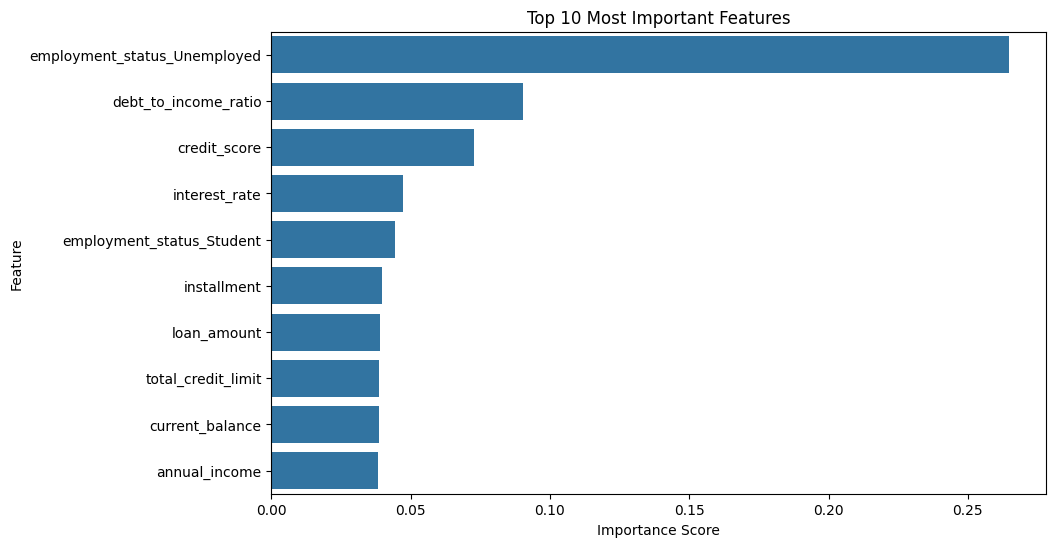

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

***Feature Importance Insight***



Feature importance analysis revealed that employment status was the most influential factor in predicting loan repayment behavior, with unemployed borrowers having a significant impact on model decisions. Debt-to-income ratio, credit score, and interest rate were also identified as key predictors, highlighting the importance of financial stability and creditworthiness in assessing loan risk. Income, loan amount, and credit utilization-related features contributed to the model's predictions as well, demonstrating that both borrower financial capacity and existing debt obligations influence repayment outcomes.

##Conclusion


This project aimed to predict loan repayment behavior using borrower financial and credit-related information. After performing data cleaning, exploratory data analysis, feature encoding, train-test splitting, and feature scaling, three machine learning models were evaluated: Logistic Regression, Decision Tree, and Random Forest.


The Logistic Regression model achieved an accuracy of 88.08%, while the Decision Tree model achieved 82.65%. Among the evaluated models, the Random Forest classifier delivered the best performance with an accuracy of 89.45%, making it the selected final model for this project.


Feature importance analysis revealed that employment status, debt-to-income ratio, credit score, and interest rate were the most influential factors in predicting loan repayment behavior. These findings highlight the significant role of employment stability, financial obligations, and creditworthiness in assessing borrower risk.


The final Random Forest model can be used to support loan approval and risk assessment decisions by predicting the likelihood of loan repayment for new applicants. To enable real-world usage, the trained model can be deployed through a FastAPI application, allowing users and businesses to obtain predictions through a simple API interface.

##Final Business Insight


Borrowers with stable employment, lower debt-to-income ratios, higher credit scores, and favorable credit profiles were more likely to repay loans successfully. The Random Forest model demonstrated strong predictive performance and provides a practical solution for identifying potential loan repayment risk.

In [32]:
import joblib

joblib.dump(rf_model, "loan_default_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "model_columns.pkl")

['model_columns.pkl']

In [34]:
from google.colab import files  # downloading model to the disk

files.download("loan_default_model.pkl")
files.download("scaler.pkl")
files.download("model_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>